当前系统是 Windows
当前项目的文件夹路径: C:\Users\16142\PycharmProjects\DeepNav
9
(1408, 5)


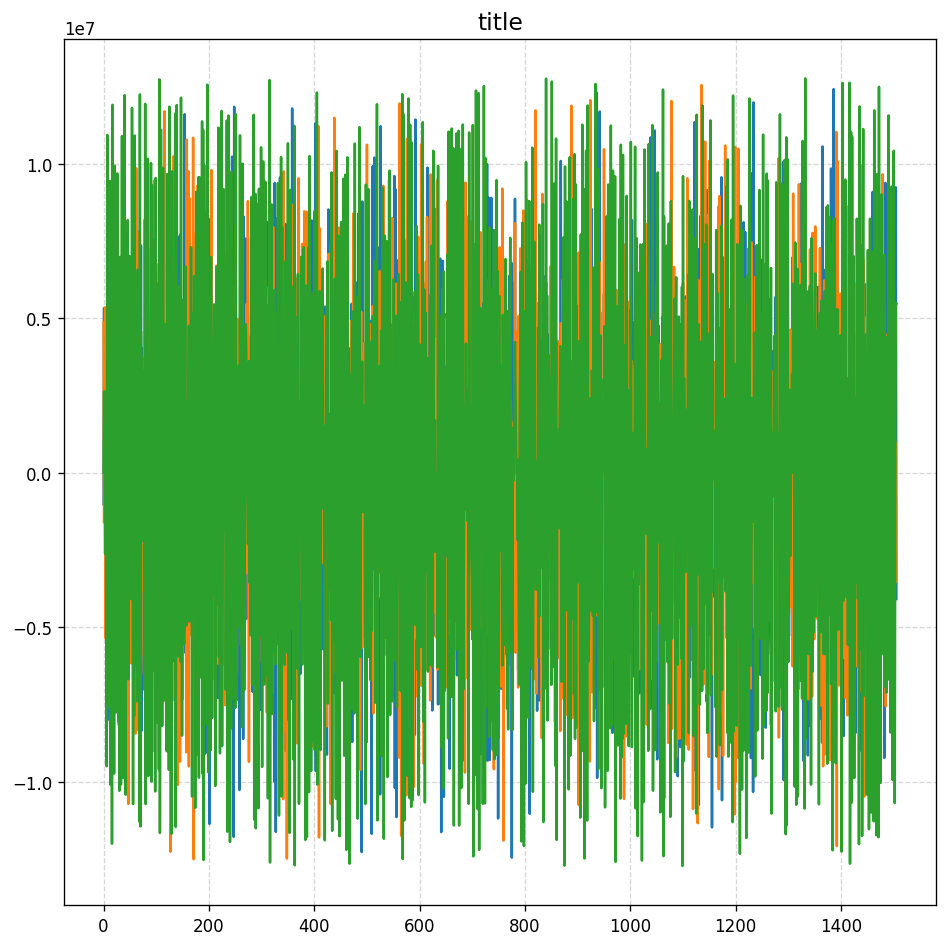

In [11]:
from pathlib import Path
from ekf import geoparams
from my_utils import plot_utils
from my_utils.os_utils import get_current_project_folder

import pandas as pd
import importlib
import numpy as np


file_name = '0000_5.02'
project_path = get_current_project_folder()
result_path = project_path.joinpath('DeepNav_results')
trail_path = result_path.joinpath('trial_001')

def read_nn_output(file_path:Path):
    nn_output_path = file_path.joinpath(f'training/reconstructed/nn_output_csv/{file_name}_nn.csv')
    data = pd.read_csv(str(nn_output_path), index_col=0).to_numpy()
    return data

# 测试用
# data = read_nn_output(trail_path)

from my_utils.io_utils import get_subfolders
trail_list = get_subfolders(str(result_path.resolve()))
data_list = []
for folder in trail_list:
    data = read_nn_output(Path(folder))
    data_list.append(data)

from ekf.read_data_from_log import read_gps_data
importlib.reload(plot_utils)   # 这里 reload 的是子模块对象
# plot_utils.plot_array_list(data_list)
print(len(data_list))
print(data_list[0].shape) # (1408, 5)
timestamp, gps_lla, eph, epv, vel_lla = read_gps_data(project_path.joinpath('DeepNav_data/flight_csvs/0000_5.02'))
gps_ecef = geoparams.lla2ecef_batch(gps_lla)
gps_data_ref = np.diff(gps_ecef, axis=0)
plot_utils.plot_multidim_lines(gps_data_ref)

In [17]:
import pandas as pd

# 假设 data_list 中的数据已经加载好
# 每个 data 是一个 numpy 数组，行数可能不同，我们需要将相同 index 的列放到同一个 sheet 中

# 设置 Excel 文件的路径
excel_path = project_path.joinpath('nn_output_5.02.xlsx')

with pd.ExcelWriter(str(excel_path), engine='xlsxwriter') as writer:
    # 遍历每个 data，将其保存到不同的 sheet 中
    for idx, data in enumerate(data_list):
        # 将 numpy 数组转换为 DataFrame，并为每列命名
        df = pd.DataFrame(data, columns=[f'Column_{i+1}' for i in range(data.shape[1])])

        # 将 DataFrame 写入 Excel，sheet 名为 "Sheet_{idx+1}"
        df.to_excel(writer, sheet_name=f'Sheet_{idx+1}', index=False)

print(f"数据已保存到 {excel_path}")

数据已保存到 C:\Users\16142\PycharmProjects\DeepNav\nn_output_data.xlsx


In [18]:
df = pd.DataFrame(gps_data_ref, columns=[f'Column_{i+1}' for i in range(gps_data_ref.shape[1])])

# 设置 Excel 文件的路径
excel_path = project_path.joinpath('gps_ref_5.02.xlsx')

# 使用 pandas 将 DataFrame 写入 Excel 文件
with pd.ExcelWriter(str(excel_path), engine='xlsxwriter') as writer:
    df.to_excel(writer, sheet_name='gps_data_ref', index=False)

print(f"gps_data_ref 数据已保存到 {excel_path}")

gps_data_ref 数据已保存到 C:\Users\16142\PycharmProjects\DeepNav\gps_data_ref.xlsx
